Warnings

In [187]:
import warnings
warnings.filterwarnings('ignore')

Libraries

In [188]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

Exploring Data

In [189]:
df = pd.read_csv('BankChurnersData.csv')

In [190]:
#CLIENTNUM	Unique identifier for each customer. (Integer)
#Attrition_Flag	Flag indicating whether or not the customer has churned out. (Boolean)
#Customer_Age	Age of customer. (Integer)
#Gender	Gender of customer. (String)
#Dependent_count	Number of dependents that customer has. (Integer)
#Education_Level	Education level of customer. (String)
#Marital_Status	Marital status of customer. (String)
#Income_Category	Income category of customer. (String)
#Card_Category	Type of card held by customer. (String)
#Months_on_book	How long customer has been on the books. (Integer)
#Total_Relationship_Count	Total number of relationships customer has with the credit card provider. (Integer)
#Months_Inactive_12_mon	Number of months customer has been inactive in the last twelve months. (Integer)
#Contacts_Count_12_mon	Number of contacts customer has had in the last twelve months. (Integer)
#Credit_Limit	Credit limit of customer. (Integer)
#Total_Revolving_Bal	Total revolving balance of customer. (Integer)
#Avg_Open_To_Buy	Average open to buy ratio of customer. (Integer)
#Total_Amt_Chng_Q4_Q1	Total amount changed from quarter 4 to quarter 1. (Integer)
#Total_Trans_Amt	Total transaction amount. (Integer)
#Total_Trans_Ct	Total transaction count. (Integer)
#Total_Ct_Chng_Q4_Q1	Total count changed from quarter 4 to quarter 1. (Integer)
#Avg_Utilization_Ratio	Average utilization ratio of customer. (Integer)

In [191]:
df.columns = df.columns.str.lower().str.strip().str.title()

In [192]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Clientnum                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_Count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_On_Book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_Mon    10127 non-null  int64  
 12  Contacts_Count_12_Mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

In [193]:
df.describe()

,Clientnum,Customer_Age,Dependent_Count,Months_On_Book,Total_Relationship_Count,Months_Inactive_12_Mon,Contacts_Count_12_Mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


In [194]:
df.drop(columns=['Clientnum'], inplace=True)

In [195]:
numericalColumns = [column for column in df.columns if df[column].dtype != 'object']
numericalColumns

['Customer_Age',
 'Dependent_Count',
 'Months_On_Book',
 'Total_Relationship_Count',
 'Months_Inactive_12_Mon',
 'Contacts_Count_12_Mon',
 'Credit_Limit',
 'Total_Revolving_Bal',
 'Avg_Open_To_Buy',
 'Total_Amt_Chng_Q4_Q1',
 'Total_Trans_Amt',
 'Total_Trans_Ct',
 'Total_Ct_Chng_Q4_Q1',
 'Avg_Utilization_Ratio']

In [196]:
categoricalColumns = [column for column in df.columns if df[column].dtype == 'object']
categoricalColumns

['Attrition_Flag',
 'Gender',
 'Education_Level',
 'Marital_Status',
 'Income_Category',
 'Card_Category']

In [197]:
categoricalColumns.remove('Attrition_Flag')

In [198]:
categoricalColumns

['Gender',
 'Education_Level',
 'Marital_Status',
 'Income_Category',
 'Card_Category']

Analyzing Numerical Data

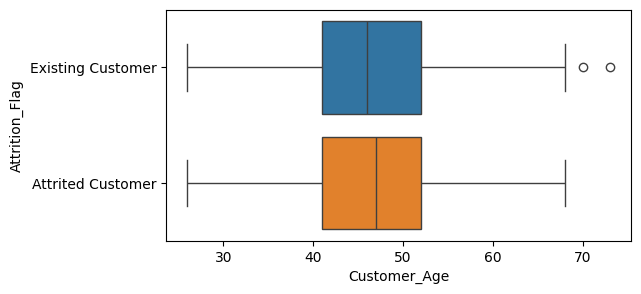

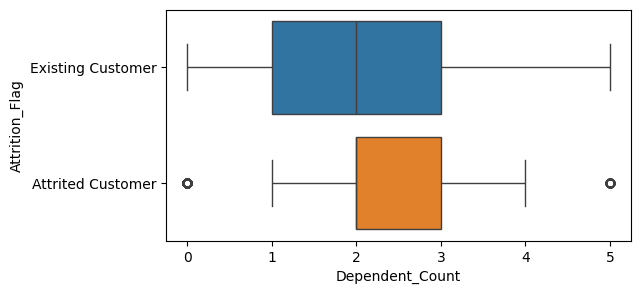

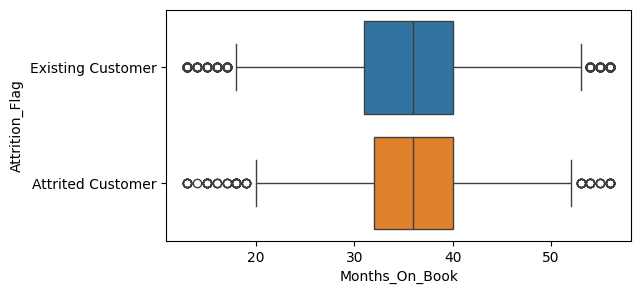

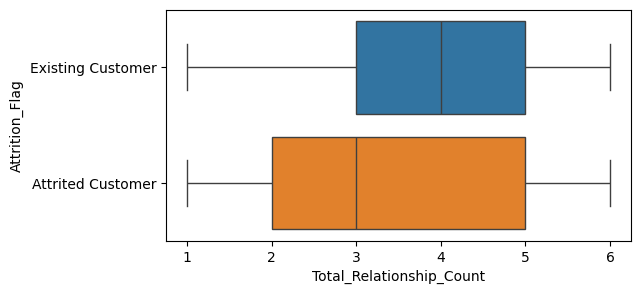

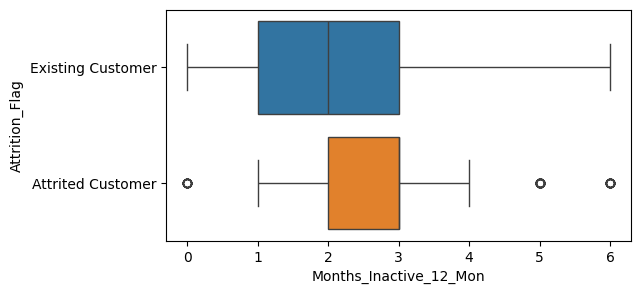

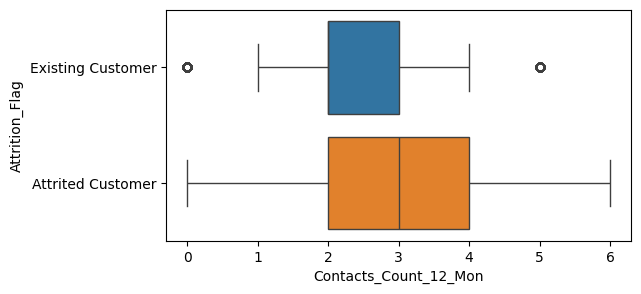

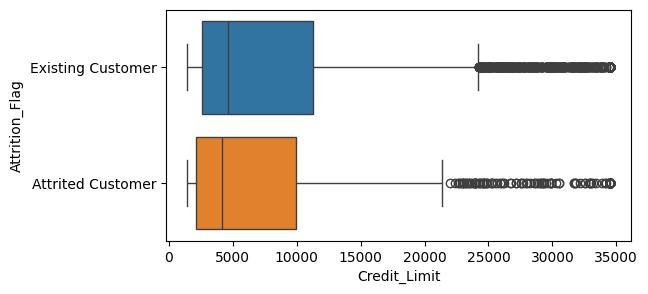

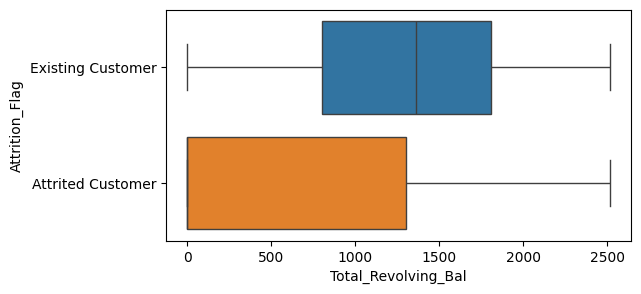

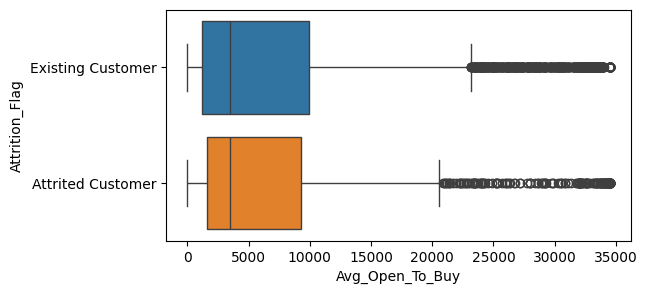

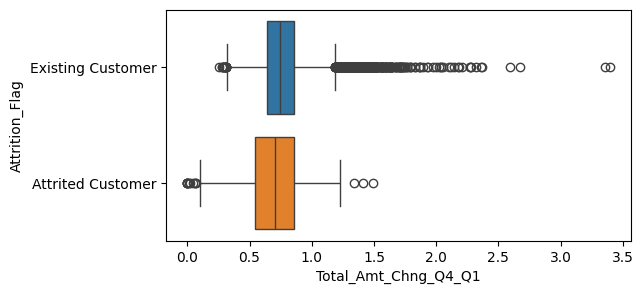

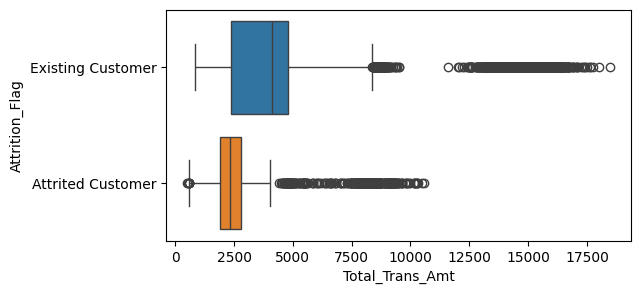

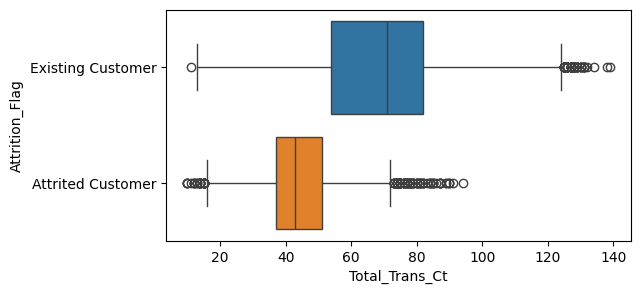

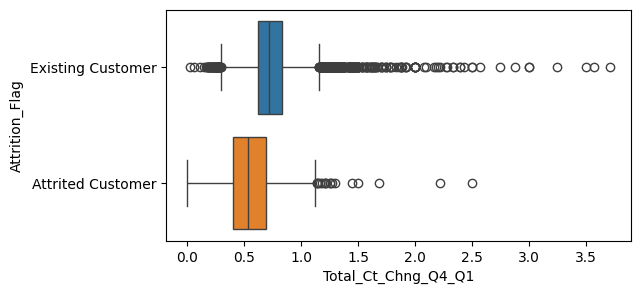

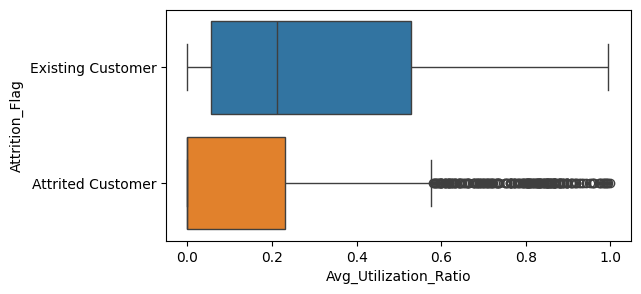

In [199]:
for column in numericalColumns:
    fig = plt.figure(figsize=(6,3))
    sns.boxplot(data=df, x=column, y='Attrition_Flag', hue='Attrition_Flag')
    plt.show()

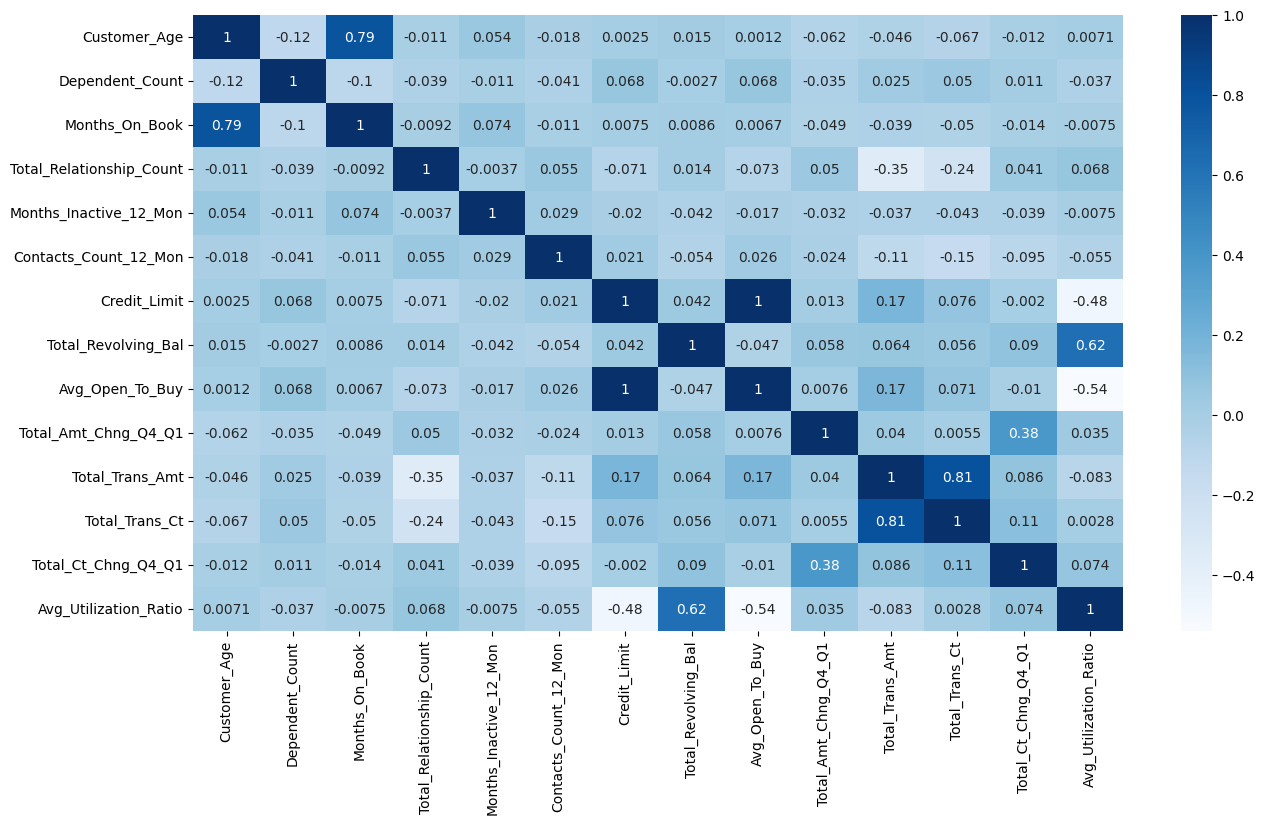

In [200]:
fig = plt.figure(figsize=(15, 8))
sns.heatmap(data=df[numericalColumns].corr(), annot=True, cmap='Blues')
plt.show()

In [201]:
(df.Avg_Open_To_Buy == df.Credit_Limit).sum()

2470

In [202]:
numericalColumns.remove('Avg_Open_To_Buy')
df.drop('Avg_Open_To_Buy', axis=1, inplace=True)

In [203]:
# Creating new feature from transaction values
df['Avg_Transaction_Value'] = df.Total_Trans_Amt/df.Total_Trans_Ct

In [204]:
numericalColumns.append('Avg_Transaction_Value')
numericalColumns.remove('Total_Trans_Amt')
df.loc[:, ['Total_Trans_Amt', 'Total_Trans_Ct', 'Avg_Transaction_Value']].head()
df.drop(columns=['Total_Trans_Amt'], inplace=True)

In [205]:
df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_Count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_On_Book,Total_Relationship_Count,Months_Inactive_12_Mon,Contacts_Count_12_Mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Avg_Transaction_Value
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,1.335,42,1.625,0.061,27.238095
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,1.541,33,3.714,0.105,39.121212
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,2.594,20,2.333,0.000,94.350000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,1.405,20,2.333,0.760,58.550000
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,2.175,28,2.500,0.000,29.142857


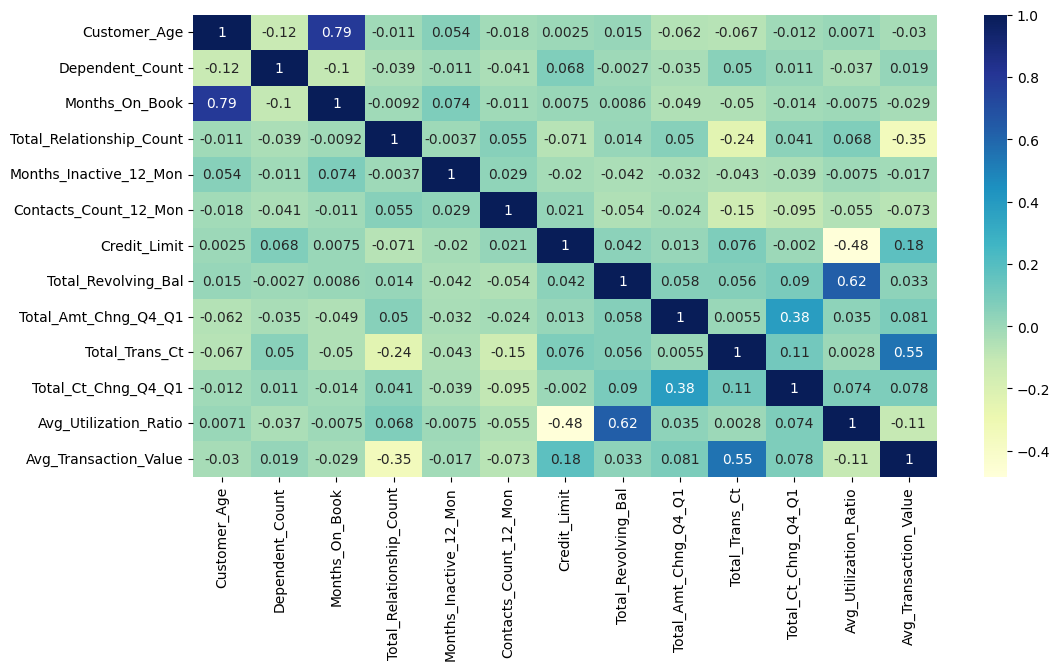

In [206]:
#Correlation of output with numerical variables

fig = plt.figure(figsize=(12, 6))
sns.heatmap(data=df[numericalColumns].corr(), annot=True, cmap='YlGnBu')
plt.show()

In [207]:
df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_Count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_On_Book,Total_Relationship_Count,Months_Inactive_12_Mon,Contacts_Count_12_Mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Avg_Transaction_Value
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,1.335,42,1.625,0.061,27.238095
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,1.541,33,3.714,0.105,39.121212
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,2.594,20,2.333,0.000,94.350000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,1.405,20,2.333,0.760,58.550000
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,2.175,28,2.500,0.000,29.142857


Creating Features

In [208]:
data = pd.get_dummies(data=df, columns=categoricalColumns, drop_first=True).replace({True: 1, False: 0})

In [209]:
data.head()

,Attrition_Flag,Customer_Age,Dependent_Count,Months_On_Book,Total_Relationship_Count,Months_Inactive_12_Mon,Contacts_Count_12_Mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,...,Marital_Status_Single,Marital_Status_Unknown,Income_Category_$40K - $60K,Income_Category_$60K - $80K,Income_Category_$80K - $120K,Income_Category_Less than $40K,Income_Category_Unknown,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
0,Existing Customer,45,3,39,5,1,3,12691.0,777,1.335,...,0,0,0,1,0,0,0,0,0,0
1,Existing Customer,49,5,44,6,1,2,8256.0,864,1.541,...,1,0,0,0,0,1,0,0,0,0
2,Existing Customer,51,3,36,4,1,0,3418.0,0,2.594,...,0,0,0,0,1,0,0,0,0,0
3,Existing Customer,40,4,34,3,4,1,3313.0,2517,1.405,...,0,1,0,0,0,1,0,0,0,0
4,Existing Customer,40,3,21,5,1,0,4716.0,0,2.175,...,0,0,0,1,0,0,0,0,0,0


Splitting Data

In [210]:
from sklearn.model_selection import train_test_split

In [211]:
y = data.pop('Attrition_Flag')
X = data

In [212]:
features = X.columns

In [213]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=42)

In [214]:
print(X_train.shape)
print(X_test.shape)
len(features)

(8101, 31)
(2026, 31)


31

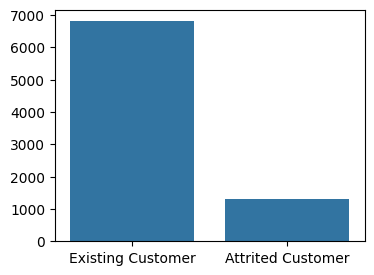

In [215]:
fig = plt.figure(figsize=(4, 3))
sns.barplot(data=Counter(y_train))
plt.show()

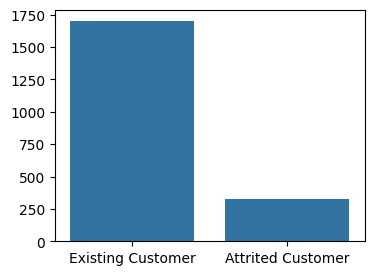

In [216]:
fig = plt.figure(figsize=(4, 3))
sns.barplot(data=Counter(y_test))
plt.show()

Scaling Data

In [217]:
from sklearn.preprocessing import MinMaxScaler

In [218]:
scaler = MinMaxScaler()

In [219]:
X_train = scaler.fit_transform(X_train)

In [220]:
X_test = scaler.transform(X_test)

Train Model

In [221]:
from sklearn import svm

In [222]:
kernel_ = 'linear'
c_ = 1.0
gamma_ = 'scale'

In [223]:
# C: Inverse regularization parameter ( high value of C - low regularization and vice versa)
# kernel: type of kernel for the model
# gamma: applicable only for RBF, polynomial and sigmoid kernel
# if gamma='scale' (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,
# if ‘auto’, uses 1 / n_features
# if float, must be non-negative.

In [224]:
model = svm.SVC(kernel=kernel_, C=c_, gamma=gamma_)

In [225]:
model.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [226]:
print(f'Indices of support vectors: {model.support_}')
print(f'Support vectors: {model.support_vectors_}')
print(f'Support vectors per class: {model.n_support_}')

Indices of support vectors: [   9   10   11 ... 8083 8089 8090]
Support vectors: [[0.15909091 0.6        0.53488372 ... 0.         0.         0.        ]
 [0.06818182 0.         0.04651163 ... 0.         0.         0.        ]
 [0.70454545 0.4        0.53488372 ... 0.         0.         0.        ]
 ...
 [0.29545455 0.6        0.46511628 ... 0.         0.         0.        ]
 [0.61363636 0.6        0.53488372 ... 0.         0.         0.        ]
 [0.61363636 0.6        0.72093023 ... 0.         0.         0.        ]]
Support vectors per class: [941 949]


Predicting

In [227]:
predictions = model.predict(X_test)

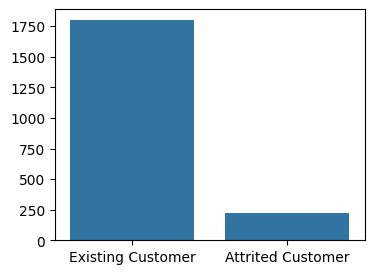

In [228]:
fig = plt.figure(figsize=(4, 3))
sns.barplot(data=Counter(predictions))
plt.show()

Evaluating Model

In [229]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve

In [230]:
confMatrix = pd.DataFrame(data=confusion_matrix(y_test, predictions), index=['P', 'N'], columns=['P', 'N'])
confMatrix

,P,N
P,182,145
N,45,1654


In [231]:
print(classification_report(y_test, predictions))

                   precision    recall  f1-score   support

Attrited Customer       0.80      0.56      0.66       327
Existing Customer       0.92      0.97      0.95      1699

         accuracy                           0.91      2026
        macro avg       0.86      0.77      0.80      2026
     weighted avg       0.90      0.91      0.90      2026



Parameter Tuning

In [232]:
from sklearn.model_selection import GridSearchCV

In [233]:
params = [
    {'C': [0.1, 1, 10, 100], 'kernel': ['linear']},
    {'C': [0.1, 1, 10, 100], 'kernel': ['rbf'], 'gamma': [0.1, 0.001, 0.0001]}
]

In [234]:
model = svm.SVC()

In [235]:
search = GridSearchCV(estimator=model, param_grid=params, cv=5, verbose=5, scoring='balanced_accuracy')

In [236]:
search.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV 1/5] END ..............C=0.1, kernel=linear;, score=0.734 total time=   0.4s
[CV 2/5] END ..............C=0.1, kernel=linear;, score=0.733 total time=   0.4s
[CV 3/5] END ..............C=0.1, kernel=linear;, score=0.740 total time=   0.4s
[CV 4/5] END ..............C=0.1, kernel=linear;, score=0.720 total time=   0.3s
[CV 5/5] END ..............C=0.1, kernel=linear;, score=0.757 total time=   0.3s
[CV 1/5] END ................C=1, kernel=linear;, score=0.781 total time=   0.3s
[CV 2/5] END ................C=1, kernel=linear;, score=0.787 total time=   0.3s
[CV 3/5] END ................C=1, kernel=linear;, score=0.777 total time=   0.3s
[CV 4/5] END ................C=1, kernel=linear;, score=0.755 total time=   0.3s
[CV 5/5] END ................C=1, kernel=linear;, score=0.804 total time=   0.3s
[CV 1/5] END ...............C=10, kernel=linear;, score=0.794 total time=   0.5s
[CV 2/5] END ...............C=10, kernel=linear;

,estimator,SVC()
,param_grid,"[{'C': [0.1, 1, ...], 'kernel': ['linear']}, {'C': [0.1, 1, ...], 'gamma': [0.1, 0.001, ...], 'kernel': ['rbf']}]"
,scoring,'balanced_accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,5
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,100


In [237]:
results = pd.DataFrame(search.cv_results_)

In [238]:
results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_kernel,param_gamma,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.393289,0.011997,0.062208,0.001940,0.1,linear,NaN,"{'C': 0.1, 'kernel': 'linear'}",0.734139,0.733399,0.739989,0.719570,0.756929,0.736805,0.012090,8
1,0.336545,0.005394,0.050959,0.004189,1.0,linear,NaN,"{'C': 1, 'kernel': 'linear'}",0.781286,0.787217,0.776697,0.754977,0.803705,0.780777,0.015809,5
2,0.554383,0.022858,0.048379,0.002304,10.0,linear,NaN,"{'C': 10, 'kernel': 'linear'}",0.794099,0.784559,0.786765,0.752319,0.808739,0.785296,0.018532,4
3,1.723334,0.069286,0.047930,0.002178,100.0,linear,NaN,"{'C': 100, 'kernel': 'linear'}",0.794467,0.784559,0.787132,0.759644,0.812585,0.787677,0.017102,3
4,0.664281,0.007306,0.214958,0.002372,0.1,rbf,0.1,"{'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}",0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.000000,11


In [239]:
results.sort_values('mean_test_score', inplace=True)

In [240]:
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_kernel,param_gamma,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
4,0.664281,0.007306,0.214958,0.002372,0.1,rbf,0.1000,"{'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}",0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.000000,11
5,0.670340,0.007668,0.211768,0.001383,0.1,rbf,0.0010,"{'C': 0.1, 'gamma': 0.001, 'kernel': 'rbf'}",0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.000000,11
6,0.591769,0.012397,0.218452,0.014670,0.1,rbf,0.0001,"{'C': 0.1, 'gamma': 0.0001, 'kernel': 'rbf'}",0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.000000,11
8,0.700405,0.030312,0.233996,0.021404,1.0,rbf,0.0010,"{'C': 1, 'gamma': 0.001, 'kernel': 'rbf'}",0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.000000,11
9,0.719809,0.034323,0.258100,0.028091,1.0,rbf,0.0001,"{'C': 1, 'gamma': 0.0001, 'kernel': 'rbf'}",0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.000000,11
12,0.687279,0.023339,0.232124,0.024135,10.0,rbf,0.0001,"{'C': 10, 'gamma': 0.0001, 'kernel': 'rbf'}",0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.000000,11
11,0.688917,0.027589,0.219378,0.004931,10.0,rbf,0.0010,"{'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}",0.500000,0.501923,0.507692,0.503846,0.501923,0.503077,0.002609,9
15,0.671171,0.016539,0.227214,0.027853,100.0,rbf,0.0001,"{'C': 100, 'gamma': 0.0001, 'kernel': 'rbf'}",0.500000,0.501923,0.507692,0.503846,0.501923,0.503077,0.002609,9
0,0.393289,0.011997,0.062208,0.001940,0.1,linear,NaN,"{'C': 0.1, 'kernel': 'linear'}",0.734139,0.733399,0.739989,0.719570,0.756929,0.736805,0.012090,8
14,0.542208,0.007049,0.180829,0.001474,100.0,rbf,0.0010,"{'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}",0.760781,0.759389,0.751980,0.740526,0.785492,0.759634,0.014790,7


Saving results

In [241]:
results.to_csv('gridSearch_results.csv')

In [242]:
print(f"Best parameters: {search.best_params_}")

Best parameters: {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}


Evaluating Best Estimator

In [248]:
modelBE = svm.SVC(C=100, gamma=0.1, kernel='rbf', class_weight='balanced')

In [249]:
modelBE.fit(X_train, y_train)

,C,100
,kernel,'rbf'
,degree,3
,gamma,0.1
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [250]:
predictions = modelBE.predict(X_test)

In [251]:
print(f"Accuracy: {accuracy_score(y_test, predictions)}")

Accuracy: 0.8933859822309971


In [252]:
print(classification_report(y_test, predictions))

                   precision    recall  f1-score   support

Attrited Customer       0.63      0.80      0.71       327
Existing Customer       0.96      0.91      0.93      1699

         accuracy                           0.89      2026
        macro avg       0.80      0.86      0.82      2026
     weighted avg       0.91      0.89      0.90      2026

